# Machine Learning Capstone Project
## Regression Track: SVR, KNN & Random Forest Regressor
**Dataset:** WHO Life Expectancy Data (`Life Expectancy Data.csv`)  
**Target Variable:** `Life expectancy` (Continuous)  

---
### Notebook Structure
1. **Dataset Loading & Audit:** Data shape, schema, missing value detection, and target summary statistics.
2. **Exploratory Data Analysis (EDA):** Target distribution, feature distributions, correlation heatmaps, and scatter plots.
3. **Data Preprocessing & Feature Engineering:** Missing value imputation, outlier handling, train-only scaling, categorical encoding, and interaction features.
4. **Model Training & Hyperparameter Tuning:**
   * K-Nearest Neighbors (KNN) Regressor
   * Support Vector Regressor (SVR)
   * Random Forest Regressor (`GridSearchCV`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Algorithms
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

## 1. Dataset Loading & Audit

In [2]:
df_raw = pd.read_csv('../data/Life Expectancy Data.csv')
df_raw.columns = df_raw.columns.str.strip()

print("="*60)
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("="*60)

audit_df = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Null Count': df_raw.isnull().sum(),
    'Null Percentage (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
})
display(audit_df[audit_df['Null Count'] > 0].sort_values(by='Null Count', ascending=False))


Dataset Shape: 2938 rows, 22 columns


,Data Type,Null Count,Null Percentage (%)
Population,float64,652,22.191967
Hepatitis B,float64,553,18.822328
GDP,float64,448,15.248468
Total expenditure,float64,226,7.692308
Alcohol,float64,194,6.603131
Income composition of resources,float64,167,5.684139
Schooling,float64,163,5.547992
thinness 5-9 years,float64,34,1.157250
thinness 1-19 years,float64,34,1.157250
BMI,float64,34,1.157250


## 2. Exploratory Data Analysis (EDA)

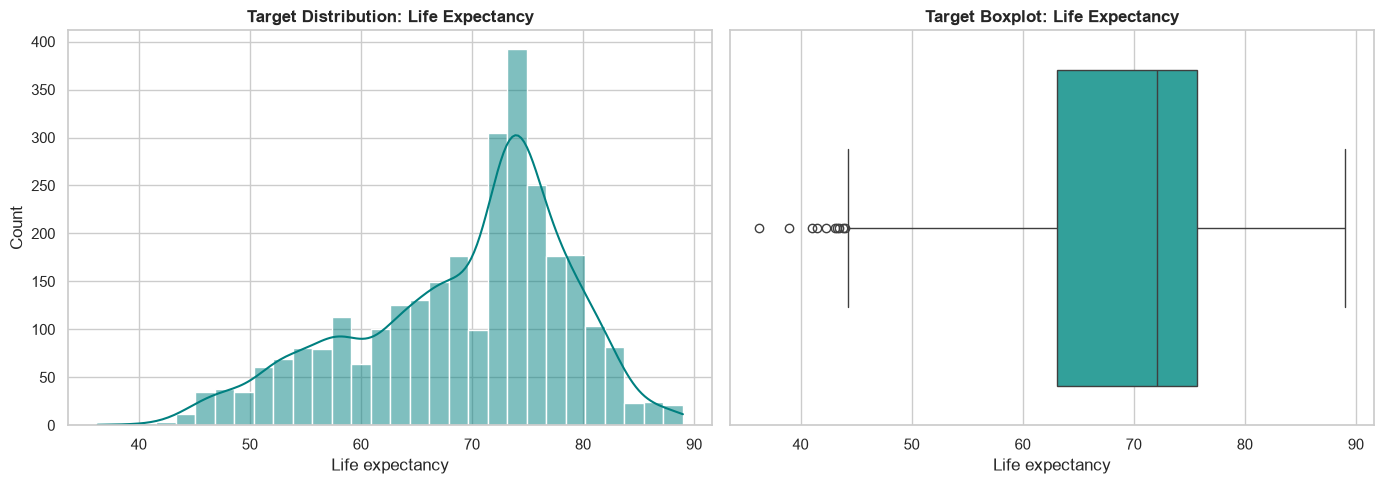

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_raw['Life expectancy'], kde=True, color='teal', ax=ax[0])
ax[0].set_title('Target Distribution: Life Expectancy', fontsize=12, fontweight='bold')

sns.boxplot(x=df_raw['Life expectancy'], color='lightseagreen', ax=ax[1])
ax[1].set_title('Target Boxplot: Life Expectancy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Feature Engineering

In [4]:
df = df_raw.dropna(subset=['Life expectancy']).copy()
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df.groupby('Status')[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

df['Status_Code'] = (df['Status'] == 'Developed').astype(int)
df['Schooling_Income_Index'] = df['Schooling'] * df['Income composition of resources']

features = [c for c in num_cols if c not in ['Life expectancy', 'Year']] + ['Status_Code', 'Schooling_Income_Index']
X = df[features]
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training shape: {X_train_scaled.shape} | Test shape: {X_test_scaled.shape}")


Training shape: (2342, 20) | Test shape: (586, 20)


## 4. Model Training & Hyperparameter Tuning

### 4.1 K-Nearest Neighbors (KNN) Regressor
Evaluate KNN Regressor across hyperparameter $k$ values on scaled input features.


In [5]:
k_values = list(range(1, 16, 2))
knn_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='r2')
    knn_scores.append(scores.mean())

best_k = k_values[np.argmax(knn_scores)]
print(f"Optimal k for KNN Regressor: {best_k} (Validation R2: {max(knn_scores):.4f})")

best_knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
best_knn.fit(X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)

r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print(f"KNN Test R2: {r2_knn:.4f} | RMSE: {rmse_knn:.4f} | MAE: {mae_knn:.4f}")


Optimal k for KNN Regressor: 5 (Validation R2: 0.9134)
KNN Test R2: 0.9154 | RMSE: 2.7056 | MAE: 1.6708


### 4.2 Support Vector Regressor (SVR)
Evaluate SVR using RBF kernel on scaled input features.


In [6]:
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
cv_svr = cross_val_score(svr, X_train_scaled, y_train, cv=5, scoring='r2').mean()

print(f"SVR Test R2: {r2_svr:.4f} | RMSE: {rmse_svr:.4f} | MAE: {mae_svr:.4f} | 5-Fold CV R2: {cv_svr:.4f}")


SVR Test R2: 0.9256 | RMSE: 2.5369 | MAE: 1.5910 | 5-Fold CV R2: 0.9190


### 4.3 Random Forest Regressor (`GridSearchCV` Tuning)
Apply `GridSearchCV` to optimize `n_estimators`, `max_depth`, and `min_samples_split`.


In [7]:
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
rf_base.fit(X_train, y_train)
r2_rf_base = r2_score(y_test, rf_base.predict(X_test))

rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [15, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), rf_param_grid, cv=5, scoring='r2', n_jobs=1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
cv_rf = rf_grid.best_score_

print("="*60)
print(f"Random Forest Best Parameters: {rf_grid.best_params_}")
print(f"RF Test R2: {r2_rf:.4f} | RMSE: {rmse_rf:.4f} | MAE: {mae_rf:.4f} | 5-Fold CV R2: {cv_rf:.4f}")
print("="*60)


Random Forest Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
RF Test R2: 0.9679 | RMSE: 1.6654 | MAE: 1.0547 | 5-Fold CV R2: 0.9584


### 4.4 Multiple Linear Regression
Train an Ordinary Least Squares (OLS) Multiple Linear Regression baseline on scaled predictor variables, evaluate generalization metrics with 5-fold cross-validation, and analyze feature coefficients and residual distributions.

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2').mean()

print(f"Linear Regression: Test R2 = {r2_lr:.4f} | RMSE = {rmse_lr:.4f} | MAE = {mae_lr:.4f} | 5-Fold CV R2 = {cv_lr:.4f}")

# Residual diagnostics & Feature coefficients
residuals_lr = y_test - y_pred_lr
coef_df_lr = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_}).sort_values(by='Coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_pred_lr, y=residuals_lr, alpha=0.6, color='steelblue', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Linear Regression: Residuals vs Predicted')
axes[0].set_xlabel('Predicted Life Expectancy')
axes[0].set_ylabel('Residuals')

sns.barplot(data=pd.concat([coef_df_lr.head(5), coef_df_lr.tail(5)]), x='Coefficient', y='Feature', palette='vlag', ax=axes[1])
axes[1].set_title('Linear Regression: Top Positive & Negative Drivers')
axes[1].set_xlabel('Standardized Coefficient Weight')
plt.tight_layout()
plt.show()

### 4.5 Ridge Regression ($L_2$ Regularization with `RidgeCV`)
Fit a Ridge Regression model with $L_2$ penalty to control multicollinearity and prevent coefficient explosion across correlated socioeconomic predictors. Hyperparameter $\alpha$ is tuned across 50 log-spaced candidates using 5-fold cross-validation.

In [ ]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
cv_ridge = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2').mean()

print(f"Ridge Regression (Optimal Alpha={ridge.alpha_:.4f}): Test R2 = {r2_ridge:.4f} | RMSE = {rmse_ridge:.4f} | MAE = {mae_ridge:.4f} | 5-Fold CV R2 = {cv_ridge:.4f}")

# Coefficient Shrinkage Comparison: OLS Linear vs Ridge
shrinkage_df = pd.DataFrame({
    'Feature': features,
    'Linear (OLS)': lr.coef_,
    'Ridge (L2)': ridge.coef_
}).melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(data=shrinkage_df, x='Feature', y='Coefficient', hue='Model', palette='coolwarm')
plt.xticks(rotation=75)
plt.title(f'Weight Regularization: OLS vs Ridge Regression (alpha = {ridge.alpha_:.4f})')
plt.ylabel('Standardized Weight')
plt.tight_layout()
plt.show()

### 4.6 Lasso Regression ($L_1$ Regularization with `LassoCV`)
Fit a Lasso Regression model with $L_1$ penalty to achieve sparse representation and intrinsic feature selection. Hyperparameter $\alpha$ is tuned via 5-fold cross-validation over 50 log-spaced candidate penalties.

In [ ]:
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, random_state=RANDOM_STATE, max_iter=2000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
cv_lasso = cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring='r2').mean()

n_selected = np.sum(lasso.coef_ != 0)
n_zeroed = np.sum(lasso.coef_ == 0)
print(f"Lasso Regression (Optimal Alpha={lasso.alpha_:.4f}): Test R2 = {r2_lasso:.4f} | RMSE = {rmse_lasso:.4f} | MAE = {mae_lasso:.4f} | 5-Fold CV R2 = {cv_lasso:.4f}")
print(f"Lasso Feature Sparsity: {n_selected}/{len(features)} features retained ({n_zeroed} zeroed out)")

# Sparsity & Feature Importance Plot
lasso_feat_df = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_}).sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
colors = ['crimson' if c == 0 else 'mediumseagreen' if c > 0 else 'cornflowerblue' for c in lasso_feat_df['Coefficient']]
sns.barplot(data=lasso_feat_df, x='Coefficient', y='Feature', palette=colors)
plt.title(f'Lasso Feature Selection (Retained: {n_selected}, Eliminated: {n_zeroed})')
plt.xlabel('Lasso Regression Coefficient')
plt.tight_layout()
plt.show()

### 4.7 Decision Tree Regressor (`GridSearchCV` Tuning)

In [11]:

dt_param_grid = {'max_depth': [5, 10, 15, 20], 'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), dt_param_grid, cv=5, scoring='r2')
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
cv_dt = dt_grid.best_score_

print(f"Decision Tree Regressor: Best Params = {dt_grid.best_params_}")
print(f"DT Test R2 = {r2_dt:.4f} | RMSE = {rmse_dt:.4f} | MAE = {mae_dt:.4f} | 5-Fold CV R2 = {cv_dt:.4f}")


Decision Tree Regressor: Best Params = {'max_depth': 10, 'min_samples_split': 10}
DT Test R2 = 0.9332 | RMSE = 2.4037 | MAE = 1.5287 | 5-Fold CV R2 = 0.9200
